---
title : "Dam Live"
---

In de toolbox Continu Inzicht wordt DAMlive gebruikt voor het realtime uitvoeren van dijksterkteanalyses. Met DAMlive kunnen voor verschillende scenario’s, op basis van hydraulische belastingen, ondergrondgegevens en de laagopbouw van de dijk, glijcirkels en veiligheidsfactoren worden berekend met behulp van diverse rekenmethodes.

De informatie en output van deze berekeningen worden door DAMlive weggeschreven in een `.stix`-bestand. Dit is een zip-bestand waarin verschillende `.json`-bestanden zijn opgeslagen.

Om de informatie en resultaten weer te geven in Continu Inzicht worden de `.json`-bestanden eerst ingelezen en omgezet naar dataframes ([parsen .json bestanden](#sec-Inladenjson)). Vervolgens worden de dataframes samengevoegd met [StageMerger](#sec-stagemerger), waarna de resultaten uiteindelijk worden geplot ([Plot stages](#sec-plotstages)).

In [24]:
# initialiseer de (toolbox continu inzicht) modules
from pathlib import Path

from toolbox_continu_inzicht.base.config import Config
from toolbox_continu_inzicht.base.data_adapter import DataAdapter
from toolbox_continu_inzicht.dam_live.combine_results import CombineDamLiveResults

De configuratie ziet er als volgt uit:

````yaml
GlobalVariables:
  rootdir: data_sets/9.dam_live_parse/WV2030_PU0013_87074-1

DataAdapter:
  scenario:
    type: stages
    path: scenarios

  geometries:
    type: geometries
    path: geometries

  soillayers:
    type: soillayers
    path: soillayers

  soils:
    type: soils
    path: soils.json

  waternets:
    type: waternets
    path: waternets

  calculationsettings:
    type: calculationsettings
    path: calculationsettings

  merge_soil:
    type: csv
    path: merged_soil.csv

  merge_waternet:
    type: csv
    path: merged_waternet.csv

  merge_calculations:
    type: csv
    path: merged_calculations.csv
````

In [25]:
config_path = (
    Path.cwd() / "data_sets" / "9.dam_live_parse" / "dam_live_parse_config.yaml"
)
config = Config(config_path=config_path)
config.lees_config()

adapter = DataAdapter(config)

## Parsen .json-bestanden{#sec-Inladenjson}

Hier worden de verschillende typen `.json`-bestanden ingeladen en omgezet naar een **dataframe** met behulp van een parser. Wanneer er meerdere `.json`-bestanden aanwezig zijn voor een bepaalde outputcategorie, worden deze samengevoegd in één dataframe.  

In het `.stix`-bestand zijn zes typen bestanden te onderscheiden:  

- **Scenario**: Bevat de stage-ID’s van de uitgevoerde berekeningen. Aan de stage-ID’s zijn geometrie, laagopbouw, waterlijnen en berekeningsresultaten gekoppeld via ID’s, die later gebruikt worden voor het mergen.  
- **Geometries**: Hier worden de verschillende lagen van de dijk gedefinieerd met lijnen.  
- **Soillayers**: Koppelt de lagen aan een specifieke grondsoort.  
- **Soils**: Bevat de eigenschappen van alle grondsoorten.  
- **Waternets**: Hier worden de waterlijnen gedefinieerd met punten.  
- **CalculationSettings**: Bevat het berekeningstype en het middelpunt en de radius van de berekende glijcirkels.


In [26]:
df_stages = adapter.input("scenario")

df_stages

,stage_id,stage_label,scenario_id,scenario_label,geometry_id,decorations_id,soillayers_id,waternet_id,waternet_creator_settings_id,state_id,state_correlations_id,loads_id,reinforcements_id,calculationsettings_id,calculation_id,content_version
0,43,Stage1,42,Scenario1,13,None,30,31,None,None,None,41,None,12,44,2


In [27]:
df_geometries = adapter.input("geometries")

df_geometries.head(5)

,geometry_id,layer_id,layer_label,points,content_version
0,13,14,Surface 14,"[{'X': 0.0, 'Z': -3.17}, {'X': 0.28, 'Z': -3.1...",2
1,13,15,Surface 15,"[{'X': 15.88, 'Z': -1.16}, {'X': 16.27, 'Z': -...",2
2,13,16,Surface 16,"[{'X': 31.75, 'Z': -0.86}, {'X': 31.94, 'Z': -...",2
3,13,17,Surface 17,"[{'X': 36.800000000000004, 'Z': -2.21}, {'X': ...",2
4,13,18,Surface 18,"[{'X': 43.02, 'Z': -3.98}, {'X': 43.67, 'Z': -...",2


In [28]:
df_soillayers = adapter.input("soillayers")

df_soillayers.head(5)

,soillayers_id,layer_id,soil_id,content_version
0,30,14,5,2
1,30,15,4,2
2,30,16,7,2
3,30,17,4,2
4,30,18,6,2


In [29]:
df_soils = adapter.input("soils")

df_soils.head(5)

,soil_id,name,code,volumetric_weight_above_phreatic_level,volumetric_weight_below_phreatic_level,shear_strength_model_type_above_phreatic_level,shear_strength_model_type_below_phreatic_level,mohr_coulomb_advanced_cohesion,mohr_coulomb_advanced_friction_angle,su_shear_strength_ratio,su_strength_increase_exponent,content_version
0,0,V_Basisveen,V_Basisveen-0,11.5,11.5,MohrCoulombAdvanced,MohrCoulombAdvanced,0.0,26.1,NaN,NaN,2
1,1,Z_Boxtel,Z_Boxtel-1,20.0,18.0,MohrCoulombAdvanced,MohrCoulombAdvanced,0.0,28.2,NaN,NaN,2
2,2,K_Wormer_zandig,K_Wormer_zandig-2,17.5,17.5,SigmaTauTable,SigmaTauTable,0.0,29.0,NaN,NaN,2
3,3,Z_Wormer_kleiig,Z_Wormer_kleiig-3,18.8,17.0,MohrCoulombAdvanced,MohrCoulombAdvanced,0.0,29.9,NaN,NaN,2
4,4,K_Antropogeen,K_Antropogeen-4,16.2,16.2,SigmaTauTable,SigmaTauTable,0.0,26.0,NaN,NaN,2


In [30]:
df_waternets = adapter.input("waternets")

df_waternets.head(5)

,waternet_id,line_type,line_id,line_label,x,z,top_headline_id,bottom_headline_id,content_version
0,31,Head,32,Phreatic line (PL 1),0.000000,-0.20,None,None,2
1,31,Head,32,Phreatic line (PL 1),18.498947,-0.20,None,None,2
2,31,Head,32,Phreatic line (PL 1),22.370000,-0.20,None,None,2
3,31,Head,32,Phreatic line (PL 1),26.950000,-0.66,None,None,2
4,31,Head,32,Phreatic line (PL 1),33.930000,-1.94,None,None,2


In [31]:
df_calculationsettings = adapter.input("calculationsettings")

df_calculationsettings.head(5)

,calculationsettings_id,analysis_type,calculation_type,model_factor_mean,model_factor_std,circle_center_x,circle_center_z,circle_radius,content_version
0,12,UpliftVan,Deterministic,1.0,0.0,43.45548,2.614191,8.644962,2
1,12,UpliftVan,Deterministic,1.0,0.0,44.19082,-3.099719,NaN,2


## StageMerger {#sec-stagemerger}

Vervolgens worden de tabellen aan elkaar gekoppeld. Hierdoor ontstaan tabellen waarin de **stage-ID** wordt gekoppeld aan de informatie uit de **Geometries**, **Soils**, **SoilLayers**, **WaterNets** en **CalculationSettings** tabellen.  

Er worden drie gekoppelde tabellen gemaakt:

- **Soil**: Koppelt de geometrie, laagopbouw en grondtypes aan de stage-ID.  
- **WaterNet**: Koppelt de locaties en typen van de waterlijnen aan de stage-ID.  
- **Calculations**: Koppelt het middelpunt en de radius van de resulterende glijcirkels aan de stage-ID.  

In [ ]:
merge_df = CombineDamLiveResults(data_adapter=adapter)
merge_df.run(
    input=[
        "scenario",
        "geometries",
        "soils",
        "soillayers",
        "waternets",
        "calculationsettings",
        "colors",
    ],
    output=["merge_soil", "merge_waternet", "merge_calculations"],
)

## Plot stage {#sec-plotstage}
Op basis van een opgegeven stage ID en de gekoppelde tabellen, kunnen de dijkopbouw, waterlijnen en resulterende glijcirkels vervolgens geplot worden

(<Figure size 1500x1500 with 1 Axes>,
 <Axes: title={'center': 'Stage 43'}, xlabel='X', ylabel='Z'>)

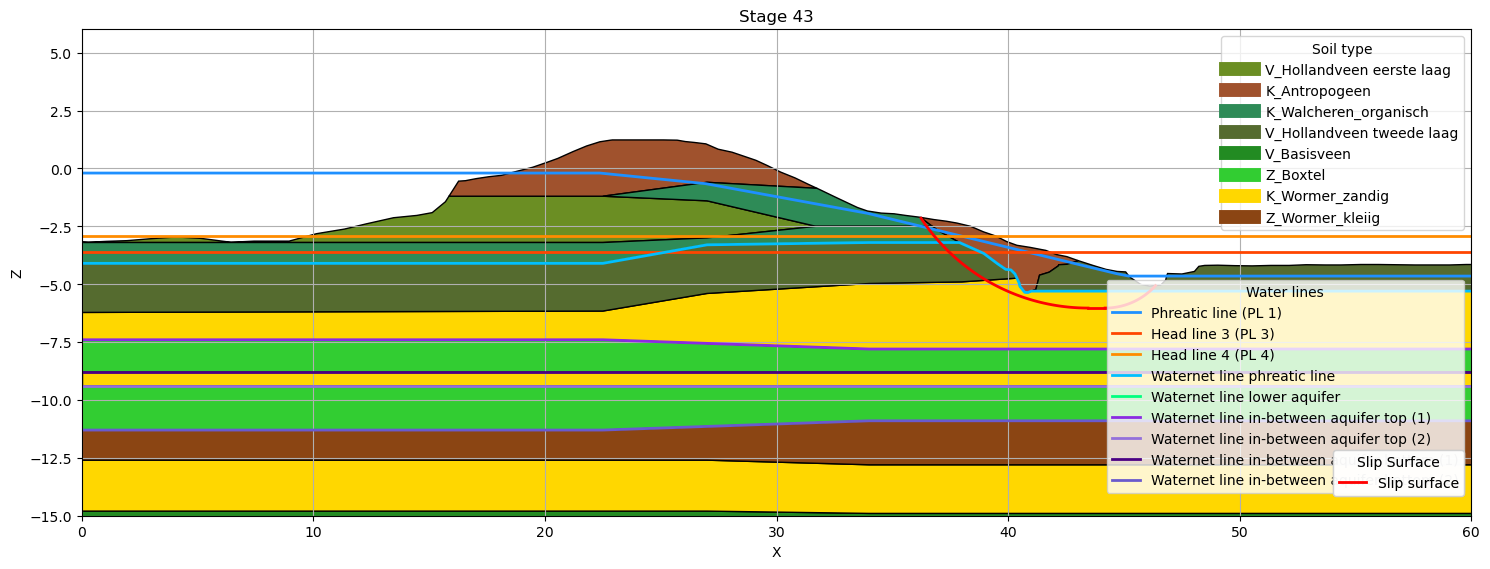

In [37]:
merge_df.plot_stage(
    stage_id=43,
    xlim=(0, 60),
    ylim=(-15, 6),
)